<a href="https://colab.research.google.com/github/ylperdomo/Calculo-Numerico/blob/Atividade-2/Atividade2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Atividade 2 - Cálculo Numérico

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6g}".format

## 1. Verificação da estabilidade

In [3]:
H = 0.01
nu = 1e-4
pontos = 21
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

previsao = []
for caso, dt in [("A", 0.001), ("B", 0.002)]:
    r = nu * dt / dy**2
    previsao.append({
        "Caso": caso,
        "Δt (s)": dt,
        "Δy (m)": dy,
        "r": r,
        "Classificação prevista": "Estável" if r <= 0.5 else "Instável",
    })

print(f"Δy = {dy:.7f} m")
print(f"Δt_max = {dt_max:.7f} s")
pd.DataFrame(previsao)

Δy = 0.0005000 m
Δt_max = 0.0012500 s


,Caso,Δt (s),Δy (m),r,Classificação prevista
0,A,0.001,0.0005,0.4,Estável
1,B,0.002,0.0005,0.8,Instável


Assim, $\Delta y=0{,}0005\ \mathrm{m}$ e $\Delta t_{\max}=0{,}00125\ \mathrm{s}$. O caso A tem $r=0{,}4$ e deve ser estável, o caso B tem $r=0{,}8$ e deve ser instável.

## 2. Detecção de overflow

In [4]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    #Coeficientes no tipo numerico escolhido
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    #Fluido parado e placa em y=0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    #Transforma avisos numericos em exceções
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                #Atualiza o interior e preserva as paredes
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


In [5]:
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

linhas = []
for nome, resultado in resultados.items():
    tipo_nome, dt_texto = nome.split(", dt=")
    linhas.append({
        "Tipo numérico": tipo_nome,
        "Δt (s)": float(dt_texto),
        "r": resultado["r"],
        "Ocorreu overflow?": "Sim" if resultado["falha"] is not None else "Não",
        "Iteração da falha": resultado["falha"] if resultado["falha"] is not None else "-",
    })

tabela_testes = pd.DataFrame(linhas)
tabela_testes

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


,Tipo numérico,Δt (s),r,Ocorreu overflow?,Iteração da falha
0,float32,0.001,0.4,Não,-
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,-
3,float64,0.002,0.8,Sim,917


Os testes confirmam a previsão: $dt = 0,001 s$ é estável, enquanto $dt = 0,002 s$ gera valores incorretos até ocorrer overflow.

## 3. Interpretação física

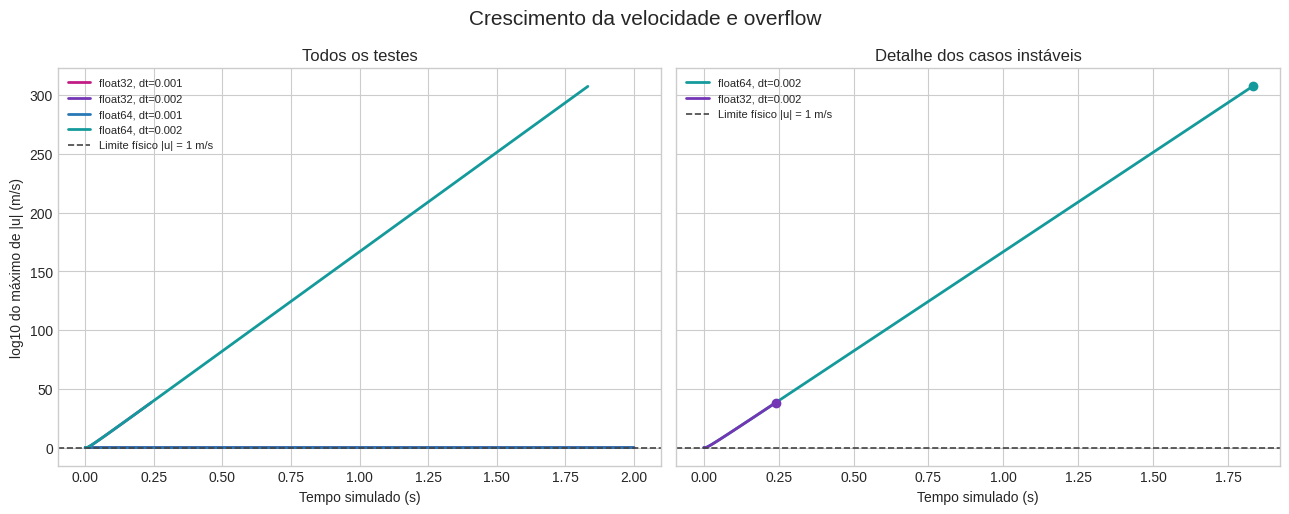

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)

#Calcula os valores em escala logarítmica
log_f32_001 = np.log10(
    np.asarray(resultados["float32, dt=0.001"]["maximos"], dtype=np.float64)
)

log_f32_002 = np.log10(
    np.asarray(resultados["float32, dt=0.002"]["maximos"], dtype=np.float64)
)

log_f64_001 = np.log10(
    np.asarray(resultados["float64, dt=0.001"]["maximos"], dtype=np.float64)
)

log_f64_002 = np.log10(
    np.asarray(resultados["float64, dt=0.002"]["maximos"], dtype=np.float64)
)

#Gráfico com todos os testes
eixos[0].plot(
    resultados["float32, dt=0.001"]["tempos"],
    log_f32_001,
    color="#C11C84",
    linewidth=2,
    label="float32, dt=0.001"
)

eixos[0].plot(
    resultados["float32, dt=0.002"]["tempos"],
    log_f32_002,
    color="#7436B5",
    linewidth=2,
    label="float32, dt=0.002"
)

eixos[0].plot(
    resultados["float64, dt=0.001"]["tempos"],
    log_f64_001,
    color="#2878B5",
    linewidth=2,
    label="float64, dt=0.001"
)

eixos[0].plot(
    resultados["float64, dt=0.002"]["tempos"],
    log_f64_002,
    color="#159A9C",
    linewidth=2,
    label="float64, dt=0.002"
)

#Detalhe dos casos instáveis
eixos[1].plot(
    resultados["float64, dt=0.002"]["tempos"],
    log_f64_002,
    color="#159A9C",
    linewidth=2,
    label="float64, dt=0.002"
)

eixos[1].plot(
    resultados["float32, dt=0.002"]["tempos"],
    log_f32_002,
    color="#7436B5",
    linewidth=2,
    label="float32, dt=0.002"
)

#Marca o último valor de cada caso instável
eixos[1].plot(
    resultados["float64, dt=0.002"]["tempos"][-1],
    log_f64_002[-1],
    "o",
    color="#159A9C",
    markersize=6
)

eixos[1].plot(
    resultados["float32, dt=0.002"]["tempos"][-1],
    log_f32_002[-1],
    "o",
    color="#7436B5",
    markersize=6
)

for eixo in eixos:
    eixo.axhline(
        0,
        color="#444444",
        linestyle="--",
        linewidth=1.2,
        label="Limite físico |u| = 1 m/s"
    )
    eixo.set_xlabel("Tempo simulado (s)")

eixos[0].set_ylabel("log10 do máximo de |u| (m/s)")
eixos[0].set_title("Todos os testes")
eixos[1].set_title("Detalhe dos casos instáveis")

eixos[0].legend(fontsize=8)
eixos[1].legend(fontsize=8)

fig.suptitle("Crescimento da velocidade e overflow", fontsize=15)
fig.tight_layout()
plt.show()

A velocidade do fluido deveria ficar entre 0 e 1 m/s, mas, como $r=0{,}8$, pequenos erros aumentam a cada passo e geram valores irreais por causa da instabilidade do método.

## 4. Capacidade de representação: `float32` versus `float64`

Usar `float64` não corrige a instabilidade, porque ela é causada pelo valor de $r$ e pelo passo de tempo escolhido. Como o `float64` consegue armazenar números muito maiores que o `float32`, ele apenas demora mais para atingir o overflow. Mas, nos dois casos as velocidades já ficam irreais antes da falha.

## 5. Refinamento da malha

In [ ]:
pontos_refinados = 41
dy_novo = H / (pontos_refinados - 1)
dt_max_novo = dy_novo**2 / (2 * nu)

print(f"Novo Δy = {dy_novo:.8f} m")
print(f"Novo Δt_max = {dt_max_novo:.8f} s")
print(f"r para Δt=0,001 s: {nu * 0.001 / dy_novo**2:.2f}")
print(f"r para Δt=0,00025 s: {nu * 0.00025 / dy_novo**2:.2f}")

Novo Δy = 0.00025000 m
Novo Δt_max = 0.00031250 s
r para Δt=0,001 s: 1.60
r para Δt=0,00025 s: 0.40


In [ ]:
refinado_instavel = simular(0.001, np.float64, passos=2000, pontos=41)
refinado_estavel = simular(0.00025, np.float64, passos=2000, pontos=41)

pd.DataFrame([
    {
        "Pontos": 41,
        "Δt (s)": 0.001,
        "r": refinado_instavel["r"],
        "Classificação": "Instável",
        "Iteração da falha": refinado_instavel["falha"],
    },
    {
        "Pontos": 41,
        "Δt (s)": 0.00025,
        "r": refinado_estavel["r"],
        "Classificação": "Estável",
        "Iteração da falha": "-" if refinado_estavel["falha"] is None else refinado_estavel["falha"],
    },
])

dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
dt=0.00025, float64: 2000 passos sem overflow.


,Pontos,Δt (s),r,Classificação,Iteração da falha
0,41,0.001,1.6,Instável,426
1,41,0.00025,0.4,Estável,-


Com a malha refinada, o novo limite é $\Delta t_{\max}=0{,}0003125\ \mathrm{s}$. Por isso, manter $\Delta t=0{,}001\ \mathrm{s}$ deixa a simulação instável, enquanto usar $\Delta t=0{,}00025\ \mathrm{s}$ recupera a estabilidade. Isso acontece porque, ao diminuir o espaçamento da malha pela metade, também é necessário reduzir o passo de tempo.

## 6. Verificação do perfil de velocidade

dt=0.00025, float64: 20000 passos sem overflow.
Tempo simulado = 5.00 s
E_infinito = 1.543210e-14 m/s


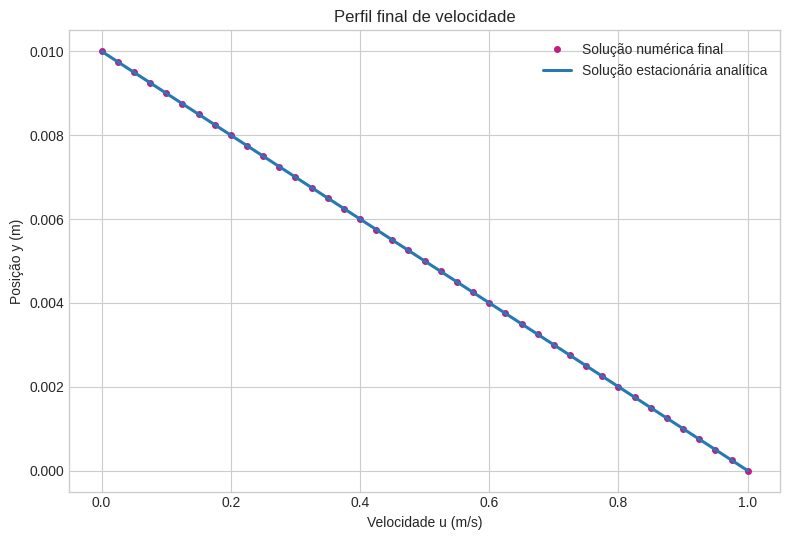

In [8]:
perfil = simular(0.00025, np.float64, passos=20000, pontos=41)

U = 1.0
u_est = U * (1 - perfil["y"] / H)
erro_infinito = np.max(np.abs(perfil["u"] - u_est))
tempo_total = 20000 * 0.00025

print(f"Tempo simulado = {tempo_total:.2f} s")
print(f"E_infinito = {erro_infinito:.6e} m/s")

plt.figure(figsize=(8, 5.5))

plt.plot(
    perfil["u"],
    perfil["y"],
    "o",
    color="#C11C84",
    markersize=4,
    label="Solução numérica final"
)

plt.plot(
    u_est,
    perfil["y"],
    color="#2878B5",
    linewidth=2.2,
    label="Solução estacionária analítica"
)

plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Perfil final de velocidade")
plt.legend()
plt.tight_layout()
plt.show()

O erro ficou próximo de zero, mostrando que os 5 s simulados foram suficientes para o fluido chegar praticamente ao regime estacionário. Por isso, o perfil numérico ficou quase igual à reta teórica, embora durante o início do movimento ele ainda fosse curvo e variasse com o tempo.

## 7. Conclusão

A simulação é estável quando $r\leq0{,}5$. Com 21 pontos, $dt = 0,001 s$ funciona, mas $dt = 0,002 s$ causa instabilidade e overflow. Usar `float64` apenas adia a falha. Ao aumentar a malha para 41 pontos, também foi necessário reduzir o passo de tempo para $dt = 0,00025 s$, mostrando que a estabilidade depende da relação entre o passo de tempo e o espaçamento da malha.